# Chapter 6: Scaling & Transformations

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib as mpl
import matplotlib.pyplot as plt

## 6.1: Introduction

Today we’ll cover key data scaling techniques like Z-score normalization and Min-Max scaling. As a data engineer, it's crucial to ensure that data is properly prepared before feeding it into various systems or pipelines. Scaling data helps standardize input values, preventing inconsistencies and ensuring smooth integration with downstream processes. Proper scaling enhances the reliability and performance of analytics, machine learning models, and data processing workflows. Let’s explore how scaling can optimize data flow and improve system efficiency.

We will be doing this by looking at the pokemon dataset that we are all familiar with by now.

In [2]:
pokemon = pd.read_csv("Pokemon.csv")
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 6.2: Statistics recap

We have seen some terms in last class related to data distribution. Specifically, we will be building upon the following terms:
- Mean
- Median
- Standard deviation

Let's calculate this for the 'Total' column.

In [3]:
pokemon['Total'].mean()

np.float64(435.1025)

In [4]:
pokemon['Total'].median()

np.float64(450.0)

In [5]:
pokemon['Total'].std()

np.float64(119.96303975551899)

Lets's also create a histogram to show this.

(array([ 2.,  8., 10.,  6.,  3., 15.,  8., 14., 13., 23., 57., 25., 38.,
        14., 20., 19.,  7., 20., 32., 19., 27., 14., 22., 27., 25., 58.,
        50., 29., 34., 27., 12.,  5.,  3., 24.,  5., 39.,  3.,  9.,  1.,
         0.,  5., 13.,  0.,  9.,  0.,  1.,  0.,  0.,  0.,  5.]),
 array([180., 192., 204., 216., 228., 240., 252., 264., 276., 288., 300.,
        312., 324., 336., 348., 360., 372., 384., 396., 408., 420., 432.,
        444., 456., 468., 480., 492., 504., 516., 528., 540., 552., 564.,
        576., 588., 600., 612., 624., 636., 648., 660., 672., 684., 696.,
        708., 720., 732., 744., 756., 768., 780.]),
 <BarContainer object of 50 artists>)

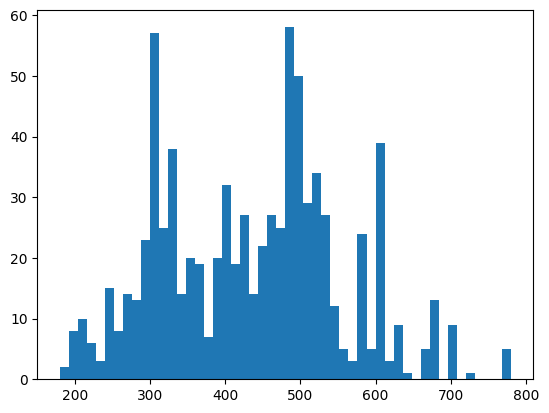

In [6]:
plt.hist(pokemon['Total'], bins = 50)

### Question 1: How can we visualise the mean and standard deviation on this plot?

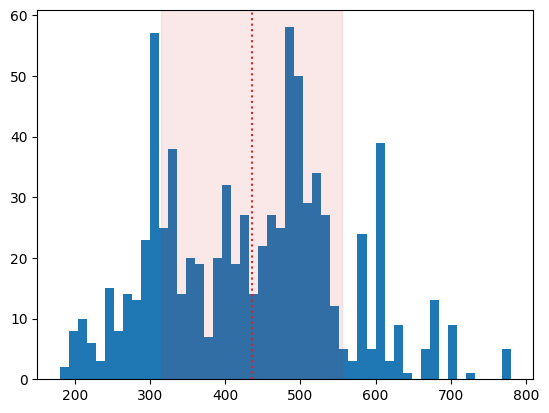

In [9]:
mean = pokemon['Total'].mean()
std = pokemon['Total'].std()

plt.hist(pokemon['Total'], bins = 50)
plt.axvline(mean, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(mean - std, mean + std, zorder = 1, color = 'tab:red', alpha = 0.1)

## 6.3: Centralization

Centering your data sounds complicated, but in reality it's really simple. All we are doing is shifting the data so the mean is placed exactly at zero. This helps reduce bias and ensures consistency across features, making data easier to process and integrate into systems. It also improves the performance and stability of various algorithms and processes downstream.

To shift the data, simply calculate the mean and substract that value from every record.

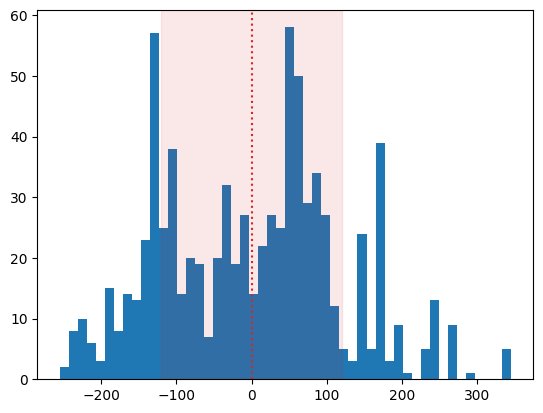

In [11]:
mean = pokemon['Total'].mean()
total_center = pokemon['Total'] - mean

mean = total_center.mean()
std = total_center.std()

plt.hist(total_center, bins=50)
plt.axvline(mean, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(mean - std, mean + std, zorder = 1, color = 'tab:red', alpha = 0.1)

### Question 2: Write a function that takes a single column as input, and outputs a centralised column instead.

In [12]:
def EnhanceData(data):
    data_center = data.mean()
    data_centralised = data - data_center
    
    return data_centralised

## 6.4: Normalization

Standardization is the process of transforming data to have a consistent scale, making it easier for systems to process and analyze. It adjusts the data so that each feature has a similar range, preventing one feature from dominating others due to differing scales.

There are two common methods for standardizing data, the first one of which is called 'Z-score normalization'.

Z-score normalization is rather similar to centralization. It will also put the median of our data at zero in order to minimise the effect of data scale. On the other hand, it will also control the spread of our data by ensuring a standard deviation of exactly one.

How does it do this? Well, simple! Just divide the dataset by the standard deviation et voila!

In [14]:
total_center_std = total_center.std()
total_zscore = total_center / total_center_std

We wouldn't be working in python if there wasn't already a method for this ;)

In [15]:
data_to_scale = pokemon['Total'].values.reshape((len(pokemon['Total']), 1))
scaler = preprocessing.StandardScaler()
scaler = scaler.fit(data_to_scale)
normalized = scaler.transform(data_to_scale)

### Question 3: Plot this data in a histogram and compare. Make sure to also visualise the median and standard deviation!

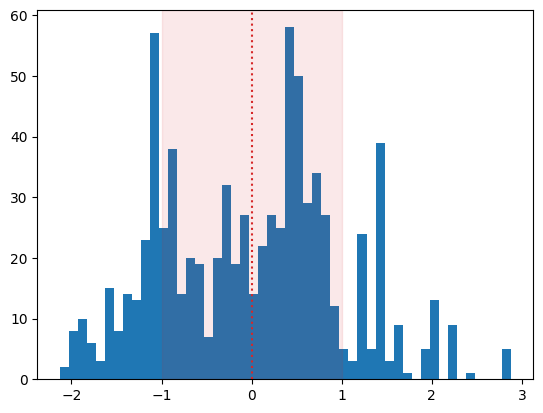

In [16]:
normalized_mean = np.mean(normalized)
normalized_std = normalized.std()

plt.hist(normalized, bins=50)
plt.axvline(normalized_mean, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(normalized_mean - normalized_std, normalized_mean + normalized_std, zorder = 1, color = 'tab:red', alpha = 0.1)

A second common normalization technique is called 'Min-Max'. It works by rescaling the data to a fixed range, typically between 0 and 1. This is escpecially helpful when data needs to be within a specific range, like for neural networks or other models sensitive to scale.

Again, python has some pre-made methods for this! They are very similar to the z-score normalization technique.

In [17]:
data_to_scale = pokemon['HP'].values.reshape((len(pokemon['Total']), 1))
scaler = preprocessing.MinMaxScaler()
scaler = scaler.fit(data_to_scale)
normalized = scaler.transform(data_to_scale)

### Question 4: Visualise the new histogram. Once again, show the median and the standard deviation. Do you notice the differences between both normalization techniques?

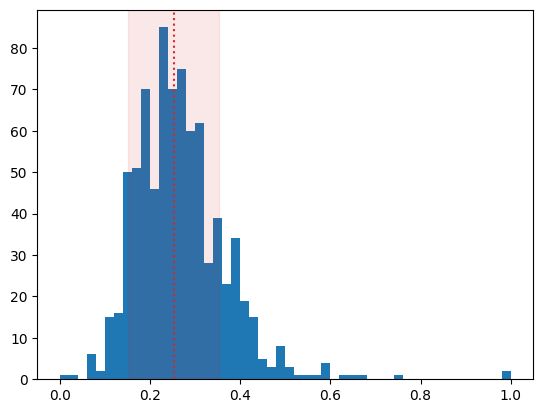

In [18]:
normalized_median = np.median(normalized)
normalized_std = normalized.std()

plt.hist(normalized, bins=50)
plt.axvline(normalized_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(normalized_median - normalized_std, normalized_median + normalized_std, zorder = 1, color = 'tab:red', alpha = 0.1)

### Question 5: Build on your previous function. Allow for an aditional string parameter to be passed which can be either 'z-score' or 'minmax' and dictates which normalization technique should be used.

In [19]:
def EnhanceData(data, technique = ''):
    data_center = data.mean()
    data_normalized = data - data_center

    if technique == 'z-score':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.StandardScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    elif technique == 'minmax':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.MinMaxScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

(array([ 29.,  73., 154.,  97., 115., 198.,  49.,  52.,  27.,   6.]),
 array([-255.1025, -195.1025, -135.1025,  -75.1025,  -15.1025,   44.8975,
         104.8975,  164.8975,  224.8975,  284.8975,  344.8975]),
 <BarContainer object of 10 artists>)

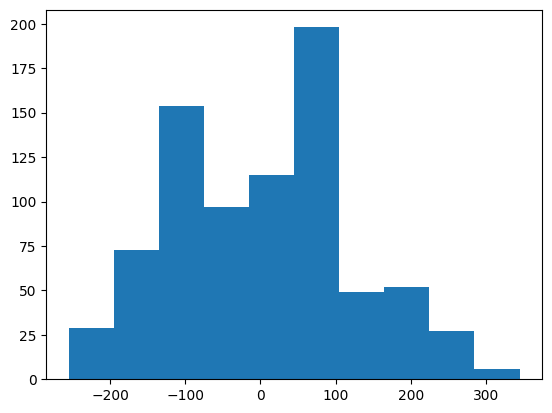

In [20]:
plt.hist(EnhanceData(pokemon['Total']))

(array([ 31.,  90., 135.,  97., 115., 207.,  77.,  15.,  27.,   6.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

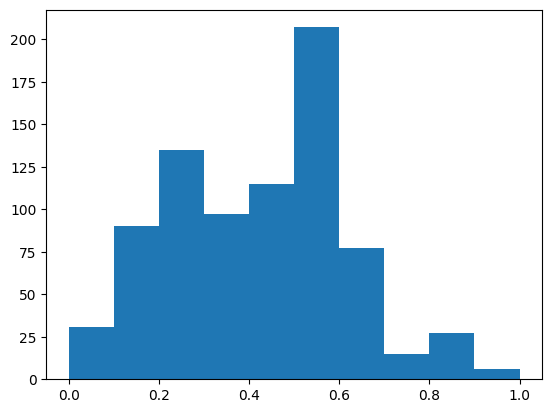

In [21]:
plt.hist(EnhanceData(pokemon['Total'], 'minmax'))

## 6.5: Transformations

Log transformations or logarithmic transformations are frequently used to make 'large things' compareable to 'small things'. Some examples are: 

- When a company sells a lot of cheap things but also really expensive things (e.g. volkswagen sells cars but also hotdogs)
- House prices (one multi million mansion can make your plot useless)

In most cases, you can simply apply a log of 10 to your data.

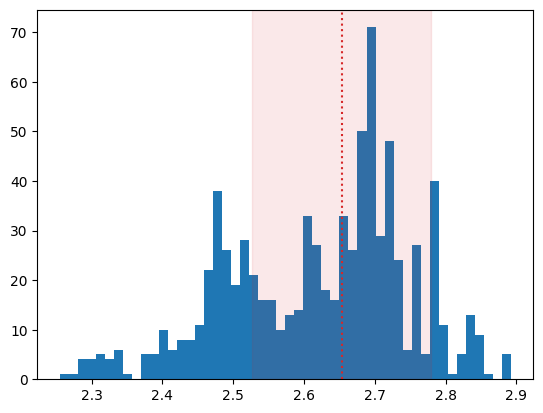

In [22]:
total_log = pokemon['Total'].apply(np.log10)

total_log_median = np.median(total_log)
total_log_std = total_log.std()

plt.hist(total_log, bins=50)
plt.axvline(total_log_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(total_log_median - total_log_std, total_log_median + total_log_std, zorder = 1, color = 'tab:red', alpha = 0.1)

### Question 6: Add logarithmic scaling to your function to create the final master data scaling and transformation function!

In [23]:
def EnhanceData(data, technique = ''):
    data_log = data.apply(np.log10)
    
    data_center = data_log.mean()
    data_normalized = data_log - data_center

    if technique == 'z-score':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.StandardScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    elif technique == 'minmax':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.MinMaxScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

(array([ 1.,  1.,  4.,  4.,  5.,  4.,  6.,  1.,  0.,  5.,  5., 10.,  6.,
         8.,  8., 11., 22., 38., 26., 19., 28., 21., 16., 16., 10., 13.,
        14., 33., 27., 18., 16., 33., 26., 50., 71., 29., 48., 24.,  6.,
        27.,  5., 40., 11.,  1.,  5., 13.,  9.,  1.,  0.,  5.]),
 array([-0.365676  , -0.35293956, -0.34020311, -0.32746667, -0.31473023,
        -0.30199379, -0.28925735, -0.2765209 , -0.26378446, -0.25104802,
        -0.23831158, -0.22557514, -0.21283869, -0.20010225, -0.18736581,
        -0.17462937, -0.16189293, -0.14915648, -0.13642004, -0.1236836 ,
        -0.11094716, -0.09821072, -0.08547427, -0.07273783, -0.06000139,
        -0.04726495, -0.03452851, -0.02179206, -0.00905562,  0.00368082,
         0.01641726,  0.0291537 ,  0.04189015,  0.05462659,  0.06736303,
         0.08009947,  0.09283591,  0.10557235,  0.1183088 ,  0.13104524,
         0.14378168,  0.15651812,  0.16925456,  0.18199101,  0.19472745,
         0.20746389,  0.22020033,  0.23293677,  0.24567322,

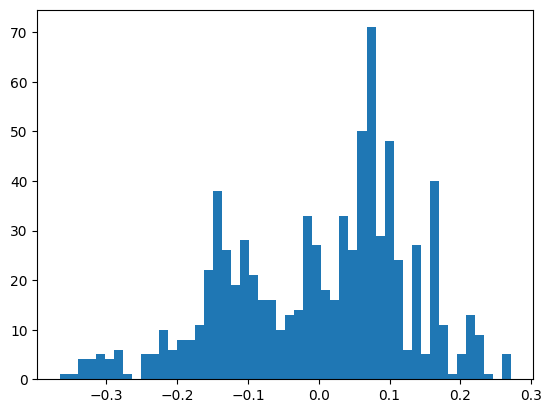

In [24]:
plt.hist(EnhanceData(pokemon["Total"], 'zscore'), bins=50)